# Cairn: a walkthrough

Cairn asks how to turn a *verified* proof (a Lean development) into a *readable* one. A formal proof fixes a dependency graph, and any order compatible with it is a valid proof. So readability becomes a choice: which results to **name**, how to **group** them, and in which **order** to present them.

This notebook retraces the project from the first blueprint parse to the blueprint-free outline tool, using two finished Lean projects as ground truth:

- **PFR**, the Polynomial Freiman–Ruzsa conjecture (additive combinatorics), a bottom-up blueprint;
- **Carleson**, Carleson's theorem (harmonic analysis), a paper-style blueprint.

Everything runs from the data committed in the repo, so you don't need a Lean install. Expensive experiments (null models with thousands of samples, LLM runs) are loaded from `results/`; cheap ones are recomputed live. The written findings are in `docs/`.

In [1]:
import json, gzip, shutil, subprocess, statistics
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw"
RES = ROOT / "results"

# Dependency dumps: committed gzipped; unpack once.
for p in ("pfr", "carleson"):
    dump = RAW / f"{p}_decls.jsonl"
    if not dump.exists():
        RAW.mkdir(parents=True, exist_ok=True)
        with gzip.open(RES / "phase1" / p / f"{p}_decls.jsonl.gz", "rb") as f, open(dump, "wb") as g:
            shutil.copyfileobj(f, g)

# Blueprint sources: cloned at pinned commits by the scripts (a few seconds, no Lean needed).
if not (RAW / "pfr" / ".git").exists():
    subprocess.run([str(ROOT / "scripts" / "phase0_pfr.sh")], check=True, capture_output=True)
if not (RAW / "carleson" / ".git").exists():
    subprocess.run([str(ROOT / "scripts" / "carleson.sh"), "--no-lean"], check=True, capture_output=True)

PFR_SRC, CAR_SRC = RAW / "pfr" / "blueprint" / "src", RAW / "carleson" / "blueprint" / "src"
PFR_DECLS, CAR_DECLS = RAW / "pfr_decls.jsonl", RAW / "carleson_decls.jsonl"
pd.set_option("display.precision", 2)

## 1. Blueprints as ground truth

A [leanblueprint](https://github.com/PatrickMassot/leanblueprint) is a LaTeX exposition in which every lemma is linked to Lean declarations (`\lean{...}`) and to the results it uses (`\uses{...}`). It records the choices a human expositor made: which results to name, how to group them into chapters, and in what order to present them. That makes it the ground truth for everything below.

In [2]:
from collections import Counter
from cairn.blueprint import parse_blueprint

pfr_bp = parse_blueprint(PFR_SRC)                          # one file per chapter
car_bp = parse_blueprint(CAR_SRC, group_by="section")      # one file; \section = chapter

for name, bp in (("PFR", pfr_bp), ("Carleson", car_bp)):
    print(f"{name}: {len(bp.nodes)} nodes, {len(bp.edges())} \\uses edges, "
          f"{len({n.chapter for n in bp.nodes})} chapters, kinds {dict(Counter(n.kind for n in bp.nodes))}")

n = pfr_bp.by_id()["shear-ent"]
print("\nExample node:", n.id, "|", n.title, "|", n.lean_decls, "| uses", n.proof_uses)
print(n.text)

PFR: 218 nodes, 497 \uses edges, 13 chapters, kinds {'lemma': 145, 'definition': 30, 'corollary': 18, 'proposition': 10, 'theorem': 15}
Carleson: 180 nodes, 220 \uses edges, 11 chapters, kinds {'theorem': 5, 'remark': 1, 'proposition': 6, 'lemma': 168}

Example node: shear-ent | Shearing preserves entropy | ['ProbabilityTheory.condEntropy_add_right', 'ProbabilityTheory.condEntropy_add_left', 'ProbabilityTheory.condEntropy_sub_right', 'ProbabilityTheory.condEntropy_sub_left'] | uses ['relabeled-entropy-cond', 'chain-rule']
If $X,Y$ are $G$-valued, then $\bbH[X \pm Y | Y]=\bbH[X|Y]$ and $\bbH[X \pm Y, Y] = \bbH[X, Y]$.


## 2. Phase 0: is the human order special?

We measure **working-memory load** as the average number of results the reader holds *open* (stated earlier and still needed later), and compare the human order with random orders that respect the dependencies. Below, the PFR `entropy` chapter is recomputed live with 300 random orders.

In [3]:
from cairn.graph import dependency_graph
from cairn.phase0 import analyse_scope

g = dependency_graph(pfr_bp)
members = [n.id for n in pfr_bp.nodes if n.chapter == "entropy"]
r = analyse_scope("entropy", g.subgraph(members).copy(), members, samples=300, uniform_samples=50)
print(f"mean open - human {r.orders['human'].mean_open:.2f}, local-search optimum {r.orders['optimised'].mean_open:.2f}, "
      f"median random {statistics.median(r.random['mean_open']):.2f}")
print(f"share of random orders better than the human order: {r.percentile('human', 'mean_open'):.0%}")

mean open - human 3.34, local-search optimum 2.79, median random 5.26
share of random orders better than the human order: 0%


The full run covers every chapter with 1,000 random orders. In every chapter the human order beats all of them, and it sits close to the load-minimising order:

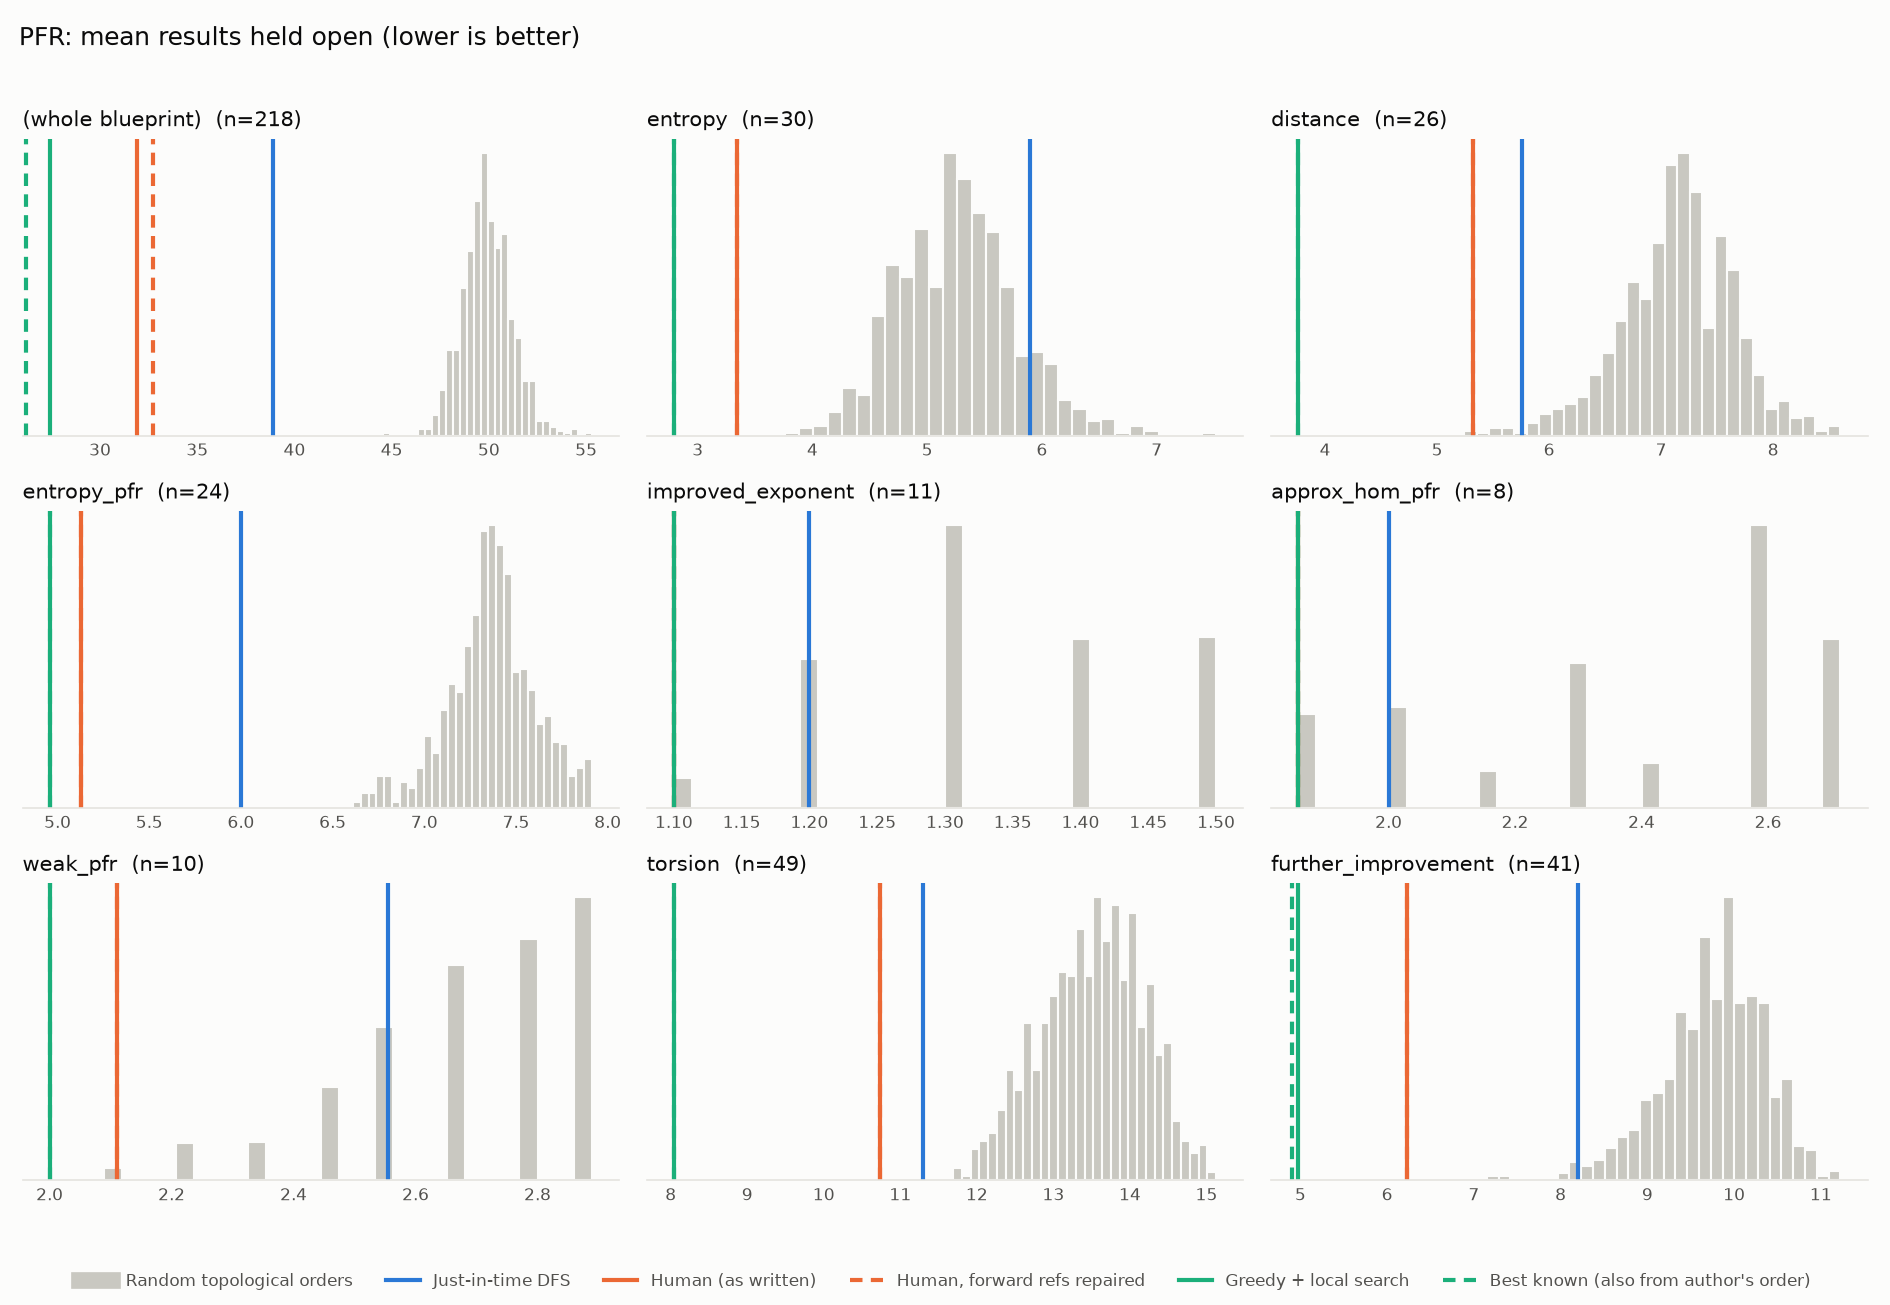

In [4]:
display(Image(str(RES / "phase0" / "pfr" / "phase0_mean_open.png"), width=900))

## 3. Phase 1: the Lean dependency graph

The authors wrote the `\uses` edges themselves, so testing their order against their own edges is circular. `lean/extract_deps.lean` dumps, for every declaration, the constants used in its statement and in its proof, plus (since the latest version) its docstring and its statement pretty-printed with the project's notation.

In [5]:
from cairn.formal import load_decls, formal_graph, join_blueprint

pfr = load_decls(PFR_DECLS)
fg = formal_graph(pfr)
join = join_blueprint(pfr_bp, pfr)
print(f"{len(pfr)} project declarations, {fg.number_of_edges()} dependency edges; "
      f"{join.coverage:.1%} of \\lean{{}} names resolve")
d = pfr["ProbabilityTheory.entropy_zero_measure"]
print("\nExample:", d.name, "\n  statement:", d.type_pp, "\n  proof uses:", sorted(d.value_deps)[:6], "...")

1395 project declarations, 5768 dependency edges; 98.4% of \lean{} names resolve

Example: ProbabilityTheory.entropy_zero_measure 
  statement: ∀ {Ω : Type u_1} {S : Type u_2} [mΩ : MeasurableSpace Ω] [inst : MeasurableSpace S] (X : Ω → S), H[X; 0] = 0 
  proof uses: ['Eq', 'Eq.trans', 'MeasurableSpace', 'MeasureTheory.Measure', 'MeasureTheory.Measure.instZero', 'MeasureTheory.Measure.map'] ...


In [6]:
p1 = json.loads((RES / "phase1" / "pfr" / "phase1.json").read_text())["stats"]["edges"]
pd.Series({
    "author \\uses edges": p1["author_edges"],
    "... also a direct Lean dependency": p1["author_direct_in_lean"],
    "... implied through a chain": p1["author_implied_transitively"],
    "... not a Lean dependency": len(p1["author_absent_from_lean"]),
    "Lean edges between blueprint nodes": p1["lean_edges"],
    "... not written by the authors": len(p1["lean_unreported_by_author"]),
}, name="PFR").to_frame()

,PFR
author \uses edges,469
... also a direct Lean dependency,407
... implied through a chain,20
... not a Lean dependency,42
Lean edges between blueprint nodes,1172
... not written by the authors,765


The authors' edges are accurate (87% of them are direct Lean dependencies) but cover only about a third of the real ones. The ones they leave out are mostly definitions and workhorse lemmas. On Lean edges the human order still beats every random order, but the within-chapter optimum is no longer so close.

## 4. Phase 2: which declarations deserve a name?

PFR has 1,395 declarations, and the blueprint names 248 of them. A logistic regression on cheap graph features (betweenness, PageRank, statement and proof size, privacy and so on) predicts which ones are named. It is cross-validated with whole Lean modules held out, and, more importantly, **across projects**.

In [7]:
kn = json.loads((RES / "phase2" / "pfr" / "phase2.json").read_text())["key_nodes"]
single = pd.DataFrame(kn["single"]).T.sort_values("auroc", ascending=False).head(6)
display(single.rename(columns={"auroc": "AUROC", "p_at_k": "precision@k"}))
display(pd.DataFrame(kn["combined"]).T[["auroc", "p_at_k"]].rename(columns={"auroc": "AUROC", "p_at_k": "precision@k"}))
transfer = json.loads((RES / "cross_project" / "key_node_transfer.json").read_text())
pd.DataFrame(transfer).T.rename(columns={"auroc": "AUROC", "p_at_k": "precision@k"})

,AUROC,precision@k
betweenness,0.79,0.53
uses (in project),0.79,0.49
"pagerank, towards results",0.77,0.52
proof size,0.76,0.46
statement size,0.74,0.44
proof / statement size,0.70,0.36


,AUROC,precision@k
structural features,0.87,0.61
+ variant-of features,0.86,0.6


,AUROC,precision@k,base_rate
PFR -> Carleson,0.85,0.3,0.07
Carleson -> PFR,0.79,0.5,0.18


The model transfers: trained on one project, it ranks the other project's named results with AUROC 0.79–0.85. This model is the selection step of the outline tool (§8).

## 5. A second project, and a better model of "order"

On Carleson the Phase 0 analysis first looked alarming: about 40% of dependency edges point *forward*, and within sections the human order seemed worse than random. The explanation, pointed out during the project, is that Carleson **states a goal, proves the lemmas it needs, and only then proves the goal**, using `\proves{}` to place a proof elsewhere.

So each result becomes two **events**: its statement `S:x` and its proof `P:x`. A proof may use anything already *stated*. Under this model most of Carleson's forward references turn out to be deferred proofs.

In [8]:
from cairn.events import event_graph, classify_edges

car = load_decls(CAR_DECLS)
for name, bp, decls in (("PFR", pfr_bp, pfr), ("Carleson", car_bp, car)):
    ev, human = event_graph(bp, decls)
    print(name, classify_edges(ev, human))
fc = car_bp.by_id()["finitary-Carleson"]
print(f"\nfinitary-Carleson: stated in section '{fc.chapter}', proved in section '{fc.proof_chapter}'")

PFR {'backward': 1348, 'deferred proofs (S before a later P)': 0, 'genuine forward references': 8}
Carleson {'backward': 453, 'deferred proofs (S before a later P)': 37, 'genuine forward references': 33}

finitary-Carleson: stated in section 'proof-of-metric-space-carleson-overview', proved in section 'proof-of-finitary-carleson'


Motivation becomes measurable: the share of lemmas stated *after* a goal they serve ("no node before the goal it serves"). PFR is about 2% motivated and Carleson about 60%. Stating goals first costs working memory, so there is a trade-off.

## 6. Style as parameters

`cairn.style.Style` makes the choice explicit, and `arrange()` always returns a valid order:

| parameter | values | meaning |
|---|---|---|
| `top_down` | 0 … 1 | share of results given "state now, prove later" treatment |
| `roadmap` | none / chapter / document | announce main results early |
| `definitions` | just-in-time / upfront | where definitions go |
| `goal_rule` | fan-in / support / key | which results become goals first |

Live: sweep `top_down` on Carleson, whole document, chapters intact.

In [9]:
from cairn.style import Style, evaluate_document, document_profile

ev, human = event_graph(car_bp, car)
rows = {f"top_down={td}": evaluate_document(ev, human, Style(td), runs=2) for td in (0, 0.4, 1.0)}
rows["human"] = document_profile(ev, human)
pd.DataFrame(rows).T[["motivated", "mean_open", "tau"]]

,motivated,mean_open,tau
top_down=0,0.04,10.65,0.85
top_down=0.4,0.67,11.61,0.84
top_down=1.0,0.98,12.62,0.84
human,0.60,12.65,1.00


The full sweep across both projects and all roadmap settings is below. `top_down` is the efficient lever, and a document-level overview is dominated. Fitting the parameters to each blueprint separates the two authors: PFR fits `top_down = 0` (pure bottom-up), while Carleson fits `top_down = 0.2` with a chapter roadmap.

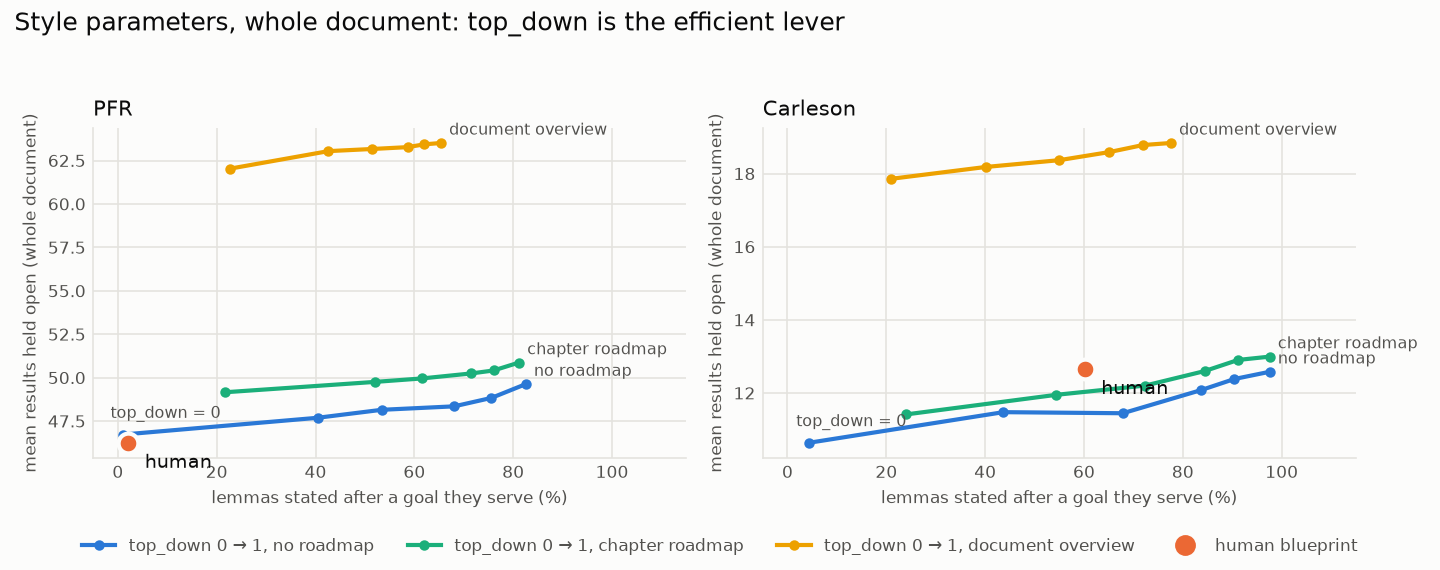

In [10]:
display(Image(str(RES / "cross_project" / "style_frontier.png"), width=950))

## 7. What does an LLM do?

As a baseline, the current Claude model (run via subagents) ordered each chapter from statements and dependency constraints alone, in two versions: node-level (each proof straight after its statement) and event-level (proofs may be deferred). Labels were optionally anonymised.

In [11]:
order = ["human", "bottom-up (m = ∞)", "node-level LLM, labelled", "node-level LLM, anonymised",
         "event-level LLM, labelled", "event-level LLM, anonymised"]
cols = {}
for p, name in (("pfr", "PFR"), ("carleson", "Carleson")):
    s = json.loads((RES / "events" / p / "llm_eval.json").read_text())["summary"]
    cols[(name, "τ with human")] = [f"{s[k]['tau_mean']:+.2f}" for k in order]
    cols[(name, "motivated")] = [f"{s[k]['motivated']:.0%}" for k in order]
pd.DataFrame(cols, index=order)

PFR               Carleson          
                            τ with human motivated τ with human motivated
human                              +1.00        2%        +1.00       67%
bottom-up (m = ∞)                  +0.53        1%        +0.12       25%
node-level LLM, labelled           +0.86        1%        +0.39       25%
node-level LLM, anonymised         +0.85        1%        +0.33       25%
event-level LLM, labelled          +0.58       29%        +0.49       56%
event-level LLM, anonymised        +0.52       29%        +0.46       56%

On PFR the LLM reproduces the bottom-up order well (τ 0.86), but letting it defer proofs makes it worse. On Carleson, deferral helps (0.39 → 0.49). Anonymising labels barely matters. The model has its own middle style, so a tool should tell it which style to use.

## 8. The end-to-end tool: a blueprint-free outline

`cairn outline` takes only the Lean dump and a key-declaration model trained on *other* projects:

1. **select** the top `detail` share of declarations as named results (optionally `--root` a main theorem);
2. **fold** every other declaration into the proofs that use it;
3. **group** by Lean module and order the chapters topologically;
4. **arrange** with a `Style`;
5. **render** statements, docstrings, uses and folded helpers.

Live: outline the proof of `PFR_conjecture` with a model trained only on Carleson.

In [12]:
from cairn.outline import KeyModel, build, render

model = KeyModel.fit({"Carleson": (car_bp, car)})
scores = model.score(pfr)
style = Style(0)  # PFR's fitted style
o = build(pfr, scores, style, detail=0.25, roots=["PFR_conjecture"])
text = render(o, pfr, "PFR conjecture: outline of the proof", style,
              f"{len(o.named)} results in {len(o.chapter_order)} chapters, from {len(pfr)} declarations.")
print(text[:1800], "\n...\n")
print(text[text.index("## 24."):][:1500])

# PFR conjecture: outline of the proof

*Generated by Cairn from Lean declarations only. Style: top_down=0. 131 results in 24 chapters, from 1395 declarations. Statements show explicit hypotheses only, with namespaces ProbabilityTheory, MeasureTheory open.*


## 1. `PFR.ForMathlib.FiniteRange.Defs`

- **Definition** `FiniteRange`
  `(X : Ω → G) : Prop`
  — The property of having a finite range.
- **Definition** `FiniteRange.fintype`
  `(X : Ω → G) [FiniteRange X] : Fintype ↑(Set.range X)`
  — fintype structure on the range of a finite range map.
- **Definition** `FiniteRange.toFinset`
  `(X : Ω → G) [FiniteRange X] : Finset G`
  — The range of a finite range map, as a finset.

## 2. `PFR.ForMathlib.FiniteRange.ConditionalProbability`

- **Theorem** `ProbabilityTheory.sum_meas_smul_cond_fiber'`
  `[MeasurableSingletonClass α] (hX : Measurable X) [FiniteRange X] (μ : Measure Ω) [IsFiniteMeasure μ] : ∑ x ∈ FiniteRange.toFinset X, μ (X ⁻¹' {x}) • μ[|X ⁻¹' {x}] = μ`
  — The **law of total p

### Prose, anchored to the Lean

The statements above are **short statements**: explicit hypotheses and instance assumptions with content (`[Finite G]`), without implicit arguments or structural instances (`[AddCommGroup G]`).

An optional LLM layer (`cairn.prose`) goes through files:
- a translator writes each chapter's title, an English statement per result and a proof sketch per theorem;
- a *separate* checker, which sees only Lean/English pairs, marks each translation faithful or not.

The committed prose for this outline is under `results/outline/prose/pfr_conjecture/`. Rendering with it puts the English first and keeps the verified Lean statement beneath it. Any translation the checker flagged gets a ⚠.

In [13]:
from cairn.prose import coverage, load_prose

prose = load_prose(RES / "outline" / "prose" / "pfr_conjecture")
text = render(o, pfr, "PFR conjecture: outline of the proof", style, "", prose=prose)
cov = coverage(o, prose)
print({k: (len(v) if isinstance(v, list) else v) for k, v in cov.items()})
print(text[text.index("## 24."):][:2500])

{'results': 131, 'translated': 131, 'checked': 131, 'flagged': 0}
## 24. The Polynomial Freiman–Ruzsa Conjecture

*Lean module `PFR.Main`*

- **Theorem** (`ProbabilityTheory.IsUniform.measureReal_preimage_sub_zero`). Let $G$ be a finite additive group in which singletons are measurable, let the ambient measure $P$ on $\Omega$ be a probability measure, and let $A, B$ be finite subsets of $G$. Let $U, V : \Omega \to G$ be measurable, independent random variables, with $U$ uniformly distributed on $A$ and $V$ uniformly distributed on $B$. Then $P[U-V=0]=\dfrac{|A\cap B|}{|A|\cdot|B|}$.
  <br>Lean: `[Finite G] [MeasurableSingletonClass G] [IsProbabilityMeasure volume] (Uunif : IsUniform (↑A) U volume) (Umeas : Measurable U) (Vunif : IsUniform (↑B) V volume) (Vmeas : Measurable V) (h_indep : IndepFun U V volume) : volume.real ((U - V) ⁻¹' {0}) = ↑(A ∩ B).card / (↑A.card * ↑B.card)`
- *Proof of* `ProbabilityTheory.IsUniform.measureReal_preimage_sub_zero`. One decomposes the event $U=V$ over 

How close do such outlines get to the human blueprints? Each project is outlined with the model trained on the other project, and the blueprint is used only for scoring:

In [14]:
frames = []
for p, name in (("pfr", "PFR"), ("carleson", "Carleson")):
    rows = json.loads((RES / "outline" / f"{p}_eval.json").read_text())["rows"]
    df = pd.DataFrame(rows)[["detail", "named_theorems", "theorem_precision", "recall", "node_coverage",
                             "chapter_nmi", "tau_whole", "tau_within_chapters"]]
    df.insert(0, "project", name)
    frames.append(df)
pd.concat(frames).set_index(["project", "detail"])

named_theorems  theorem_precision  recall  node_coverage  \
project  detail                                                             
PFR      0.05                59               0.78    0.27           0.30   
         0.10               119               0.72    0.44           0.48   
         0.15               178               0.61    0.53           0.58   
         0.20               237               0.52    0.59           0.63   
         0.30               354               0.44    0.73           0.76   
Carleson 0.05               121               0.48    0.27           0.35   
         0.10               217               0.43    0.42           0.51   
         0.15               346               0.35    0.54           0.64   
         0.20               500               0.29    0.64           0.74   
         0.30               793               0.23    0.81           0.88   

                 chapter_nmi  tau_whole  tau_within_chapters  
project  detail                                               
PFR      0.05           0.82       0.44             8.77e-01  
         0.10           0.84       0.51             6.10e-01  
         0.15           0.85       0.52             6.16e-01  
         0.20           0.84       0.53             6.07e-01  
         0.30           0.85       0.54             5.69e-01  
Carleson 0.05           0.71       0.40             7.93e-01  
         0.10           0.71       0.43             2.67e-01  
         0.15           0.72       0.47            -2.53e-02  
         0.20           0.72       0.43            -3.00e-02  
         0.30           0.73       0.41             9.96e-03

At its own level of detail, the selection is several times better than chance (base rates: 18% for PFR, 7% for Carleson). Chapters from Lean modules match the blueprint (NMI 0.71–0.85), and within-chapter order is good for PFR. Carleson's paper-style order is the part that structure alone can't recover.

## 9. Where this leaves us

What works:
- **Choosing what to name** is predictable from cheap structure, and the model transfers between projects.
- **Grouping** follows the Lean module structure.
- **Order** is a *style* choice. Bottom-up, load-minimising order reproduces PFR. `top_down` and `roadmap` move along a measurable trade-off between working memory and motivation.
- **An end-to-end outline** can now be built from any Lean development, with short statements and checked English prose.

Open threads (details in `docs/`):
- A repair loop for translations the checker flags, and a check for proof sketches.
- More blueprint projects for the key-declaration model.
- A reader model in which *announced* goals cost less than unexplained lemmas.
- Style-conditioned LLM ordering.

| doc | topic |
|---|---|
| `docs/idea-notes.md`, `docs/scope.md` | motivation and plan |
| `docs/phase0-pfr.md`, `docs/phase1-pfr.md`, `docs/phase2-pfr.md` | PFR phases |
| `docs/carleson.md` | second project, cross-project comparison |
| `docs/statement-proof-events.md` | deferred proofs, motivation vs load, LLM baselines |
| `docs/style.md` | style parameters |
| `docs/outline.md` | blueprint-free outlines |